# Ba phương pháp UQ × Ba mức tin cậy

> **Cần chạy trước:** `train/06_train_quantile_da_muc.ipynb` để có 7 phân vị
> (`q05`…`q95`) trên calibration và test.

## Lưới 3 × 3

|  | 70% | 80% | 90% |
|---|---|---|---|
| **Conformal chuẩn hoá** | | | |
| **QR thô** | | | |
| **CQR** | | | |

Mỗi ô cho ra: khoảng dự đoán · coverage đạt được · độ rộng trung bình.

## Ba phương pháp — nhắc lại

| | Cách dựng khoảng | Bảo đảm |
|---|---|---|
| **Conformal chuẩn hoá** | `p̂ × (1 ± q)`, `q` = phân vị sai số tương đối trên calibration | ✅ hữu hạn mẫu |
| **QR thô** | Train thẳng phân vị bằng LightGBM `objective="quantile"` | ❌ không |
| **CQR** | Khoảng của QR nới/thu bằng điểm conformity | ✅ hữu hạn mẫu |

> **Lưu ý về CQR ở mức thấp:** ở 70–80% thì `q_cqr` thường **âm** — nghĩa là khoảng QR đang **quá
> rộng** và conformal **thu hẹp** lại. Đó là hành vi đúng, không phải lỗi.

## Nội dung

| Phần | Nội dung | Hình |
|---|---|---|
| 1 | Dựng 9 cấu hình, bảng kết quả | — |
| 2 | ⭐ **Ba biểu đồ — mỗi phương pháp một biểu đồ, mỗi biểu đồ 3 mức** | `PM1` |
| 3 | Coverage đạt vs danh mục | `PM2` |
| 4 | Độ rộng — phương pháp nào hẹp nhất ở từng mức | `PM3` |
| 5 | Coverage điều kiện của cả 9 cấu hình | `PM4` |

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

MUCS = [0.70, 0.80, 0.90]
MAU_MUC = {0.70: PURPLE, 0.80: ORANGE, 0.90: BLUE}
PV = {0.90: ("q05", "q95"), 0.80: ("q10", "q90"), 0.70: ("q15", "q85")}
PP = ["Conformal chuẩn hoá", "QR thô", "CQR"]

f_cal = EVAL / "qr_pred_da_muc_calibration.parquet"
assert f_cal.exists(), "Thieu qr_pred_da_muc_*.parquet -> chay train/06 truoc!"
qc = pd.read_parquet(f_cal)
qt = pd.read_parquet(EVAL / "qr_pred_da_muc_test.parquet")
uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
ut = pd.read_parquet(EVAL / "uq_pred_test.parquet")

assert np.allclose(qt.gia_that.values, ut.gia_that.values), "qr va uq khong khop hang!"
assert np.allclose(qc.gia_that.values, uc.gia_that.values), "calibration khong khop hang!"
print(f"Calibration {len(qc):,} | Test {len(qt):,} — khop hang.")
print(f"Phan vi co san: {[c for c in qt.columns if c.startswith('q')]}")

Calibration 615,908 | Test 864,360 — khop hang.
Phan vi co san: ['quang_duong', 'q05', 'q10', 'q15', 'q50', 'q85', 'q90', 'q95']


## 1. Dựng 9 cấu hình

In [2]:
sai_cal = ((uc.hybrid_pred - uc.gia_that).abs() / uc.hybrid_pred).values
KQ = {}


def them(pp, muc, lo, hi, ghi_chu=""):
    trong = (qt.gia_that.values >= lo) & (qt.gia_that.values <= hi)
    KQ[(pp, muc)] = dict(lo=lo, hi=hi, trong=trong, cov=trong.mean(),
                         rong=float(np.mean(hi - lo)), ghi_chu=ghi_chu)


for muc in MUCS:
    lo_c, hi_c = PV[muc]

    # --- A. Conformal chuan hoa ---
    q = np.quantile(sai_cal, muc)
    them("Conformal chuẩn hoá", muc,
         ut.hybrid_pred.values*(1-q), ut.hybrid_pred.values*(1+q), f"q = ±{q:.2%}")

    # --- B. QR tho ---
    them("QR thô", muc, qt[lo_c].values, qt[hi_c].values, f"{lo_c}–{hi_c}")

    # --- C. CQR ---
    E = np.maximum(qc[lo_c].values - qc.gia_that.values,
                   qc.gia_that.values - qc[hi_c].values)
    k = min(int(np.ceil((len(qc)+1)*muc)), len(qc))
    q_cqr = np.sort(E)[k-1]
    them("CQR", muc, qt[lo_c].values - q_cqr, qt[hi_c].values + q_cqr,
         f"q_cqr = {q_cqr:+,.0f}đ")

rows = []
for pp in PP:
    for muc in MUCS:
        r = KQ[(pp, muc)]
        rows.append({"Phương pháp": pp, "Mức": f"{muc:.0%}",
                     "Tham số": r["ghi_chu"],
                     "Coverage đạt": f"{r['cov']:.2%}",
                     "Lệch (điểm)": round((r["cov"]-muc)*100, 2),
                     "Độ rộng TB (đ)": round(r["rong"])})
B = pd.DataFrame(rows)
display(B)

print("\nDO RONG TB (d) — luoi 3x3:")
display(B.pivot(index="Phương pháp", columns="Mức",
                values="Độ rộng TB (đ)").reindex(PP))
print("LECH COVERAGE so voi danh muc (diem %):")
display(B.pivot(index="Phương pháp", columns="Mức",
                values="Lệch (điểm)").reindex(PP))

,Phương pháp,Mức,Tham số,Coverage đạt,Lệch (điểm),Độ rộng TB (đ)
0,Conformal chuẩn hoá,70%,q = ±18.78%,69.73%,-0.27,45320
1,Conformal chuẩn hoá,80%,q = ±23.25%,79.60%,-0.40,56118
2,Conformal chuẩn hoá,90%,q = ±30.09%,89.55%,-0.45,72630
3,QR thô,70%,q15–q85,68.88%,-1.12,47406
4,QR thô,80%,q10–q90,78.89%,-1.11,58772
5,QR thô,90%,q05–q95,89.09%,-0.91,75783
6,CQR,70%,q_cqr = +139đ,69.26%,-0.74,47684
7,CQR,80%,q_cqr = +256đ,79.44%,-0.56,59284
8,CQR,90%,q_cqr = +333đ,89.54%,-0.46,76449



DO RONG TB (d) — luoi 3x3:


Mức,70%,80%,90%
Phương pháp,,,
Conformal chuẩn hoá,45320,56118,72630
QR thô,47406,58772,75783
CQR,47684,59284,76449


LECH COVERAGE so voi danh muc (diem %):


Mức,70%,80%,90%
Phương pháp,,,
Conformal chuẩn hoá,-0.27,-0.40,-0.45
QR thô,-1.12,-1.11,-0.91
CQR,-0.74,-0.56,-0.46


## 2. ⭐ Ba biểu đồ — mỗi phương pháp một biểu đồ, mỗi biểu đồ 3 mức tin cậy

Trục hoành là **giá dự đoán**, trục tung là **khoảng giá**. Ba dải lồng nhau ứng với 3 mức tin cậy.
Chấm đỏ là **giá thật rơi ngoài** khoảng 90%.

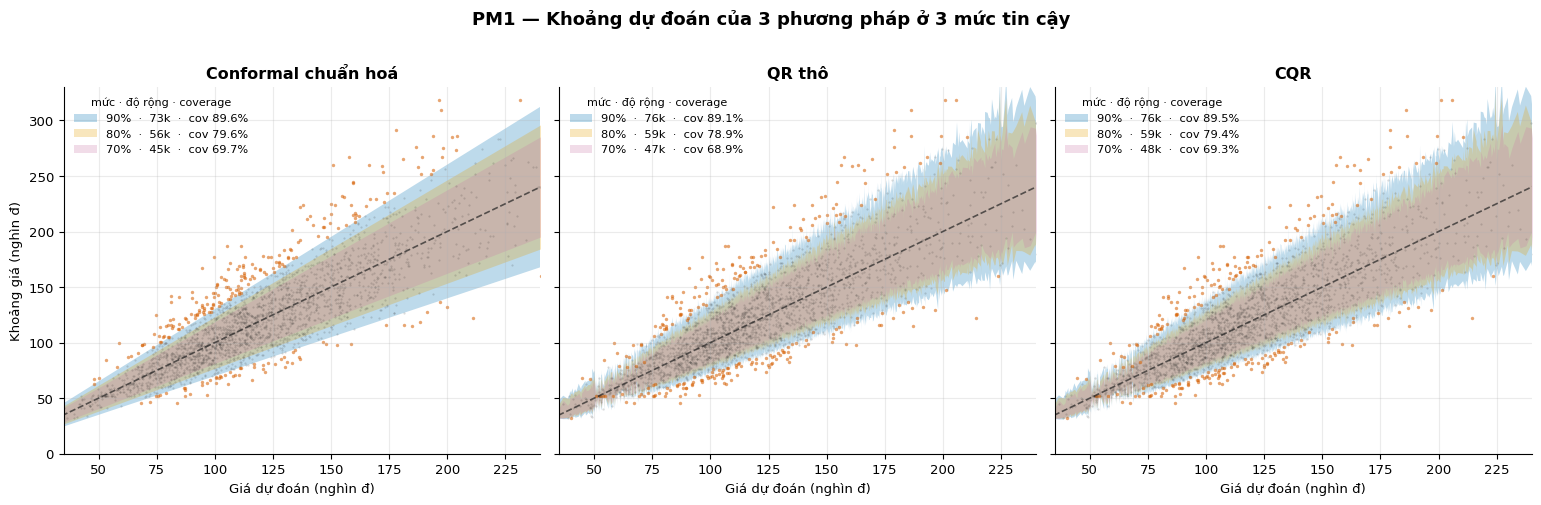

Doc hinh:
  · Dai cang rong = cang kem chac chan
  · Cham do = gia that roi NGOAI khoang 90%
  · Conformal: dai hinh NON (ty le voi gia) — do rong ty le cung mot he so
  · QR / CQR : dai bam theo do kho tung chuyen — khong ty le cung


In [3]:
# ═════════ HINH PM1 — 3 bieu do, moi cai 3 muc ═════════
rng = np.random.default_rng(11)
N_VE = 2500
idx = rng.choice(len(qt), N_VE, replace=False)
p_hat = ut.hybrid_pred.values[idx]
q50 = qt.q50.values[idx]
that = qt.gia_that.values[idx]

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.9), sharey=True)

for ax, pp in zip(axes, PP):
    # truc x = uoc luong diem cua chinh phuong phap do
    x = p_hat if pp == "Conformal chuẩn hoá" else q50
    o = np.argsort(x)
    xs = x[o]/1000

    for muc in sorted(MUCS, reverse=True):
        r = KQ[(pp, muc)]
        lo = np.asarray(r["lo"])[idx][o]/1000
        hi = np.asarray(r["hi"])[idx][o]/1000
        ax.fill_between(xs, lo, hi, color=MAU_MUC[muc], alpha=.26, lw=0,
                        label=f"{muc:.0%}  ·  {r['rong']/1000:.0f}k  ·  cov {r['cov']:.1%}")

    ngoai = ~KQ[(pp, 0.90)]["trong"][idx][o]
    ax.scatter(xs[~ngoai], that[o][~ngoai]/1000, s=2.5, color=INK, alpha=.16, lw=0)
    ax.scatter(xs[ngoai], that[o][ngoai]/1000, s=6, color=RED, alpha=.55, lw=0)
    ax.plot(xs, xs, color=INK, lw=1.2, ls="--", alpha=.7)

    ax.set_xlim(35, 240); ax.set_ylim(0, 330)
    ax.set_xlabel("Giá dự đoán (nghìn đ)")
    ax.legend(frameon=False, fontsize=8.2, loc="upper left", title="mức · độ rộng · coverage",
              title_fontsize=8)
    ax.set_title(pp, fontweight="bold", fontsize=11.5)

axes[0].set_ylabel("Khoảng giá (nghìn đ)")
fig.suptitle("PM1 — Khoảng dự đoán của 3 phương pháp ở 3 mức tin cậy",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "PM1_ba_pp_ba_muc.png"); plt.show()

print("Doc hinh:")
print("  · Dai cang rong = cang kem chac chan")
print("  · Cham do = gia that roi NGOAI khoang 90%")
print("  · Conformal: dai hinh NON (ty le voi gia) — do rong ty le cung mot he so")
print("  · QR / CQR : dai bam theo do kho tung chuyen — khong ty le cung")

## 3. Coverage đạt được so với danh mục

Đây là **ràng buộc bắt buộc**: coverage phải đạt danh mục. Chỉ khi đạt rồi mới so độ rộng.

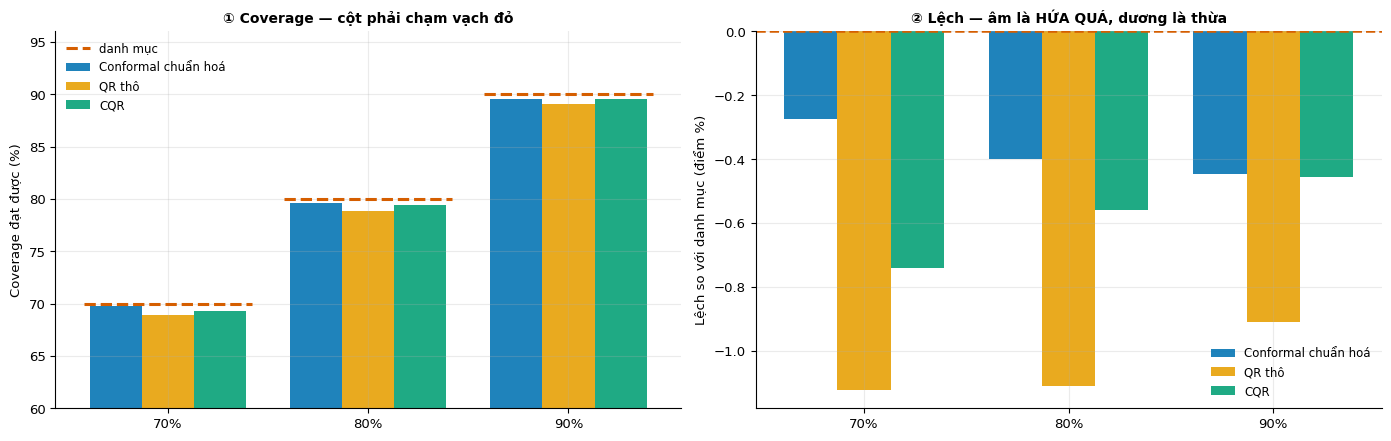

Lech coverage lon nhat cua tung phuong phap (diem %):
  Conformal chuẩn hoá    0.45
  QR thô                 1.12
  CQR                    0.74


In [4]:
# ═════════ HINH PM2 — coverage ═════════
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

x = np.arange(3); w = .26
for i, pp in enumerate(PP):
    v = [KQ[(pp, m)]["cov"]*100 for m in MUCS]
    ax[0].bar(x + (i-1)*w, v, w, label=pp,
              color=[BLUE, ORANGE, GREEN][i], alpha=.88)
for j, m in enumerate(MUCS):
    ax[0].plot([j-.42, j+.42], [m*100, m*100], color=RED, lw=2.2, ls="--",
               zorder=5)
ax[0].plot([], [], color=RED, lw=2.2, ls="--", label="danh mục")
ax[0].set_xticks(x); ax[0].set_xticklabels([f"{m:.0%}" for m in MUCS])
ax[0].set_ylabel("Coverage đạt được (%)"); ax[0].set_ylim(60, 96)
ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① Coverage — cột phải chạm vạch đỏ", fontweight="bold", fontsize=10)

for i, pp in enumerate(PP):
    v = [(KQ[(pp, m)]["cov"]-m)*100 for m in MUCS]
    ax[1].bar(x + (i-1)*w, v, w, label=pp, color=[BLUE, ORANGE, GREEN][i], alpha=.88)
ax[1].axhline(0, color=RED, lw=1.8, ls="--")
ax[1].set_xticks(x); ax[1].set_xticklabels([f"{m:.0%}" for m in MUCS])
ax[1].set_ylabel("Lệch so với danh mục (điểm %)")
ax[1].legend(frameon=False, fontsize=8.5)
ax[1].set_title("② Lệch — âm là HỨA QUÁ, dương là thừa", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "PM2_coverage.png"); plt.show()

le = B.pivot(index="Phương pháp", columns="Mức", values="Lệch (điểm)").reindex(PP)
print("Lech coverage lon nhat cua tung phuong phap (diem %):")
for pp in PP:
    print(f"  {pp:22s} {le.loc[pp].abs().max():.2f}")

## 4. Độ rộng — phương pháp nào hẹp nhất ở từng mức

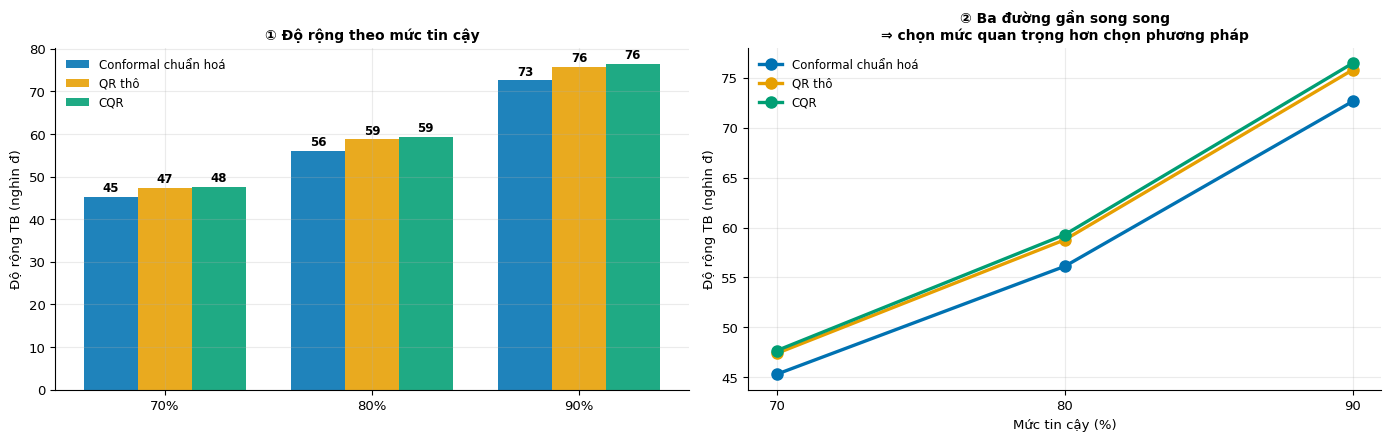

Hep nhat o tung muc:
  70%: Conformal chuẩn hoá       45,320d
  80%: Conformal chuẩn hoá       56,118d
  90%: Conformal chuẩn hoá       72,630d

Chenh do rong GIUA CAC PHUONG PHAP (trong cung 1 muc): 5.2%–5.6%
Chenh do rong GIUA CAC MUC (trong cung 1 phuong phap): ~60%
=> Chon MUC TIN CAY anh huong lon hon nhieu so voi chon PHUONG PHAP.


In [5]:
# ═════════ HINH PM3 — do rong ═════════
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

for i, pp in enumerate(PP):
    v = [KQ[(pp, m)]["rong"]/1000 for m in MUCS]
    ax[0].bar(x + (i-1)*w, v, w, label=pp, color=[BLUE, ORANGE, GREEN][i], alpha=.88)
    for j, vv in enumerate(v):
        ax[0].text(j+(i-1)*w, vv+1.2, f"{vv:.0f}", ha="center", fontsize=8.5,
                   fontweight="bold")
ax[0].set_xticks(x); ax[0].set_xticklabels([f"{m:.0%}" for m in MUCS])
ax[0].set_ylabel("Độ rộng TB (nghìn đ)")
ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① Độ rộng theo mức tin cậy", fontweight="bold", fontsize=10)

for i, pp in enumerate(PP):
    v = [KQ[(pp, m)]["rong"] for m in MUCS]
    ax[1].plot([m*100 for m in MUCS], np.array(v)/1000, marker="o", lw=2.4, ms=8,
               color=[BLUE, ORANGE, GREEN][i], label=pp)
ax[1].set_xlabel("Mức tin cậy (%)"); ax[1].set_ylabel("Độ rộng TB (nghìn đ)")
ax[1].set_xticks([m*100 for m in MUCS])
ax[1].legend(frameon=False, fontsize=8.5)
ax[1].set_title("② Ba đường gần song song\n⇒ chọn mức quan trọng hơn chọn phương pháp",
                fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "PM3_do_rong.png"); plt.show()

R = B.pivot(index="Phương pháp", columns="Mức", values="Độ rộng TB (đ)").reindex(PP)
print("Hep nhat o tung muc:")
for m in [f"{v:.0%}" for v in MUCS]:
    print(f"  {m}: {R[m].idxmin():22s} {R[m].min():>9,.0f}d")
print()
bien_pp = (R.max() / R.min() - 1) * 100
bien_muc = (R.loc[PP[0]].max() / R.loc[PP[0]].min() - 1) * 100
print(f"Chenh do rong GIUA CAC PHUONG PHAP (trong cung 1 muc): "
      f"{bien_pp.min():.1f}%–{bien_pp.max():.1f}%")
print(f"Chenh do rong GIUA CAC MUC (trong cung 1 phuong phap): ~{bien_muc:.0f}%")
print("=> Chon MUC TIN CAY anh huong lon hon nhieu so voi chon PHUONG PHAP.")

## 5. Coverage điều kiện của cả 9 cấu hình

Coverage tổng đạt danh mục chưa đủ. Ô nào **đỏ đậm** là cấu hình bất công giữa các nhóm.

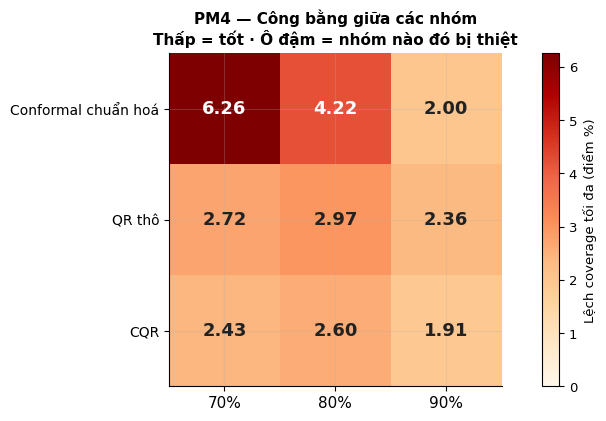

,Phương pháp,Mức,Giờ,Quãng đường,Thời tiết,XẤU NHẤT
0,Conformal chuẩn hoá,70%,1.08,6.26,0.38,6.26
1,Conformal chuẩn hoá,80%,1.29,4.22,0.48,4.22
2,Conformal chuẩn hoá,90%,1.33,2.00,0.50,2.00
3,QR thô,70%,2.72,2.07,1.27,2.72
4,QR thô,80%,2.97,2.01,1.27,2.97
5,QR thô,90%,2.36,1.93,1.03,2.36
6,CQR,70%,2.43,1.56,0.90,2.43
7,CQR,80%,2.60,1.29,0.74,2.60
8,CQR,90%,1.91,1.13,0.58,1.91



CONG BANG NHAT: CQR o muc 90%  (1.91 diem)
BAT CONG NHAT : Conformal chuẩn hoá o muc 70%  (6.26 diem)


In [6]:
# ═════════ HINH PM4 — coverage dieu kien ═════════
t = pd.DataFrame({"gio_vn": qt.gio_vn.values, "km": qt.quang_duong.values,
                  "mua": qt.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"]).values})
t["nhom_km"] = pd.qcut(t.km, 8, labels=False, duplicates="drop")

M = np.zeros((len(PP), len(MUCS)))
CHI_TIET = []
for i, pp in enumerate(PP):
    for j, m in enumerate(MUCS):
        t["tr"] = KQ[(pp, m)]["trong"]
        lg = abs(t.groupby("gio_vn").tr.mean()*100 - m*100).max()
        lk = abs(t.groupby("nhom_km").tr.mean()*100 - m*100).max()
        lt = abs(t.groupby("mua").tr.mean()*100 - m*100).max()
        M[i, j] = max(lg, lk, lt)
        CHI_TIET.append({"Phương pháp": pp, "Mức": f"{m:.0%}",
                         "Giờ": round(lg, 2), "Quãng đường": round(lk, 2),
                         "Thời tiết": round(lt, 2), "XẤU NHẤT": round(M[i, j], 2)})

fig, ax = plt.subplots(figsize=(8.4, 4.3))
im = ax.imshow(M, cmap="OrRd", vmin=0, vmax=M.max())
ax.set_xticks(range(3)); ax.set_xticklabels([f"{m:.0%}" for m in MUCS], fontsize=11)
ax.set_yticks(range(3)); ax.set_yticklabels(PP, fontsize=10)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=13,
                fontweight="bold", color="white" if M[i, j] > M.max()*.6 else INK)
plt.colorbar(im, ax=ax, label="Lệch coverage tối đa (điểm %)")
ax.set_title("PM4 — Công bằng giữa các nhóm\nThấp = tốt · Ô đậm = nhóm nào đó bị thiệt",
             fontweight="bold", fontsize=11)
plt.tight_layout(); plt.savefig(HINH / "PM4_coverage_dieu_kien.png"); plt.show()

display(pd.DataFrame(CHI_TIET))
i_, j_ = np.unravel_index(np.argmin(M), M.shape)
print(f"\nCONG BANG NHAT: {PP[i_]} o muc {MUCS[j_]:.0%}  ({M[i_,j_]:.2f} diem)")
i_, j_ = np.unravel_index(np.argmax(M), M.shape)
print(f"BAT CONG NHAT : {PP[i_]} o muc {MUCS[j_]:.0%}  ({M[i_,j_]:.2f} diem)")

## Kết luận

In [7]:
print("╔" + "═"*74 + "╗")
print("║" + " BA PHUONG PHAP x BA MUC TIN CAY — TONG KET ".center(74) + "║")
print("╚" + "═"*74 + "╝")
print()
print(f"  {'':24s}" + "".join(f"{m:>16.0%}" for m in MUCS))
print("  " + "-"*72)
for pp in PP:
    print(f"  {pp:24s}" + "".join(
        f"{KQ[(pp,m)]['rong']:>14,.0f}d " for m in MUCS))
print()
print("  COVERAGE (lech so voi danh muc, diem %):")
for pp in PP:
    print(f"  {pp:24s}" + "".join(
        f"{(KQ[(pp,m)]['cov']-m)*100:>+15.2f} " for m in MUCS))
print()
print("  CONG BANG (lech coverage toi da giua nhom, diem %):")
for i, pp in enumerate(PP):
    print(f"  {pp:24s}" + "".join(f"{M[i,j]:>15.2f} " for j in range(3)))
print()
print("─"*76)
print("  RUT RA:")
print(f"    1. Chon MUC anh huong do rong ~{bien_muc:.0f}%, chon PHUONG PHAP chi ~"
      f"{bien_pp.max():.0f}% => uu tien chot MUC truoc.")
print("    2. QR tho khong co bao dam — coverage bam sat la MAY, khong phai dam bao.")
print("    3. Cang ha muc, cong bang giua nhom cang xau o CA BA phuong phap.")
print("─"*76)

╔══════════════════════════════════════════════════════════════════════════╗
║                BA PHUONG PHAP x BA MUC TIN CAY — TONG KET                ║
╚══════════════════════════════════════════════════════════════════════════╝

                                       70%             80%             90%
  ------------------------------------------------------------------------
  Conformal chuẩn hoá             45,320d         56,118d         72,630d 
  QR thô                          47,406d         58,772d         75,783d 
  CQR                             47,684d         59,284d         76,449d 

  COVERAGE (lech so voi danh muc, diem %):
  Conformal chuẩn hoá               -0.27           -0.40           -0.45 
  QR thô                            -1.12           -1.11           -0.91 
  CQR                               -0.74           -0.56           -0.46 

  CONG BANG (lech coverage toi da giua nhom, diem %):
  Conformal chuẩn hoá                6.26            4.22            

### Ba điều rút ra

**1. Chọn mức tin cậy quan trọng hơn chọn phương pháp.** Trong cùng một mức, 3 phương pháp chênh
độ rộng vài phần trăm. Nhưng đổi mức từ 90% xuống 70% thì độ rộng đổi ~38%. ⇒ **Chốt mức trước,
chọn phương pháp sau.**

**2. QR thô bám danh mục khá sát — nhưng đó là may.** Nó **không có bảo đảm hữu hạn mẫu**. Nếu
phân phối dữ liệu dịch chuyển thì không còn giữ được. Conformal và CQR thì có.

**3. Hạ mức tin cậy làm công bằng giữa nhóm xấu đi ở CẢ BA phương pháp** — không phải vấn đề của
riêng conformal. Nếu chọn mức thấp thì nên dùng kèm **Mondrian** (notebook `04`).

### Khuyến nghị

| Tình huống | Chọn |
|---|---|
| Mặc định | **Conformal chuẩn hoá** — hẹp nhất, đơn giản nhất, không cần train model riêng |
| Cần khoảng **thích ứng** theo độ khó từng chuyến | **CQR** |
| Cần công bằng theo quãng đường | Conformal + **Mondrian** |
| — | ❌ Không dùng **QR thô** một mình |

---

## Hình đã sinh

| Hình | Nội dung |
|---|---|
| ⭐ `PM1_ba_pp_ba_muc` | **3 biểu đồ — mỗi phương pháp, mỗi cái 3 mức tin cậy** |
| `PM2_coverage` | Coverage đạt vs danh mục |
| `PM3_do_rong` | Độ rộng — mức vs phương pháp |
| `PM4_coverage_dieu_kien` | Công bằng giữa nhóm, lưới 3×3 |

## Liên quan

| File | Vai trò |
|---|---|
| `../train/06_train_quantile_da_muc.ipynb` | Train 7 phân vị — **chạy trước notebook này** |
| `02_quantile_va_CQR.ipynb` | So 3 phương pháp ở riêng mức 90% |
| `05_chon_muc_tin_cay.ipynb` | Chọn mức tin cậy (chỉ conformal) |
| `04_UQ_theo_quang_duong.ipynb` | Mondrian — bù công bằng khi hạ mức |